In [ ]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

SEED = 42

# Site calibration 
RUH_TRUST_KWH_ELEC = 64_500_000
RUH_TRUST_FLOOR_M2 = 101_132
SITE_INTENSITY_KWH_PER_M2 = RUH_TRUST_KWH_ELEC / RUH_TRUST_FLOOR_M2

BLOCK_FLOOR_M2   = 6_000
BLOCK_ANNUAL_KWH = SITE_INTENSITY_KWH_PER_M2 * BLOCK_FLOOR_M2
BLOCK_WEEKLY_KWH = BLOCK_ANNUAL_KWH / 52

WARD_SETPOINT = 22.0 

In [2]:
def fetch_bath_weather(start, end):
    """Open-Meteo historical API, hourly 2 m temperature for Bath."""
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=51.3781&longitude=-2.3597"
        f"&start_date={start}&end_date={end}"
        "&hourly=temperature_2m&timezone=Europe/London"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    d = r.json()["hourly"]
    return pd.DataFrame({
        "timestamp": pd.to_datetime(d["time"]),
        "outside_temp_c": d["temperature_2m"],
    }).set_index("timestamp")

def fetch_grid_ci(start, end):
    """NESO Carbon Intensity API, 30-min UK average intensity."""
    url = (f"https://api.carbonintensity.org.uk/intensity/"
           f"{start}T00:00Z/{end}T23:30Z")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    rows = r.json()["data"]
    return pd.DataFrame([{
        "timestamp": pd.to_datetime(x["from"]).tz_convert(None),
        "grid_ci_gco2_per_kwh": x["intensity"]["actual"]
                                 or x["intensity"]["forecast"],
    } for x in rows]).set_index("timestamp")

In [ ]:
def build_week(start, end, season_label, out_csv):
    """Construct one synthetic week and save to CSV."""
    rng = np.random.default_rng(SEED)
    idx = pd.date_range(start=start, end=f"{end} 23:45", freq="15min")
    df = pd.DataFrame(index=idx)
    df.index.name = "timestamp"

    # Weather
    w = fetch_bath_weather(start, end)
    df["outside_temp_c"] = (w["outside_temp_c"].reindex(df.index)
                            .interpolate("linear").bfill().ffill())
    ci = fetch_grid_ci(start, end)
    df["grid_ci_gco2_per_kwh"] = (ci["grid_ci_gco2_per_kwh"]
                                  .reindex(df.index)
                                  .interpolate("linear").bfill().ffill())

    # Tariff
    hours = df.index.hour + df.index.minute / 60
    tariff = (15
              + 8 * np.sin((hours - 18) * np.pi / 12)
              + 3 * np.sin((hours - 8) * np.pi / 12))
    tariff += 0.03 * (df["grid_ci_gco2_per_kwh"]
                      - df["grid_ci_gco2_per_kwh"].mean())
    df["tariff_p_per_kwh"] = tariff.clip(lower=5, upper=40)

    # Theatre schedule
    def theatre(ts):
        h = ts.hour + ts.minute / 60
        if ts.dayofweek < 5:
            if 8.5 <= h < 12.5:  return int(rng.random() < 0.90)
            if 12.5 <= h < 13.5: return int(rng.random() < 0.35)
            if 13.5 <= h < 17.5: return int(rng.random() < 0.85)
            if 17.5 <= h < 20:   return int(rng.random() < 0.25)
            return int(rng.random() < 0.05)
        return int(rng.random() < 0.12)
    t1 = np.array([theatre(t) for t in df.index])
    t2 = np.array([theatre(t) for t in df.index])
    df["theatre_load_kw"] = t1*45 + (1-t1)*5 + t2*45 + (1-t2)*5

    # MRI schedule
    def mri(ts):
        return int(ts.dayofweek < 6 and 8 <= ts.hour < 20
                   and rng.random() < 0.70)
    m = np.array([mri(t) for t in df.index])
    df["mri_load_kw"] = m*30 + (1-m)*8

    # Ward activity index
    act = np.zeros(len(df))
    for i, t in enumerate(df.index):
        h = t.hour + t.minute / 60
        if t.dayofweek < 5:
            act[i] = (0.6
                      + 0.30*np.exp(-((h-9)**2)/2)
                      + 0.25*np.exp(-((h-15.5)**2)/3)
                      - 0.20*np.exp(-((h-3)**2)/4))
        else:
            act[i] = 0.55 + 0.30*np.exp(-((h-14)**2)/4)
    df["ward_activity_index"] = np.clip(
        act + rng.normal(0, 0.03, len(df)), 0.2, 1.0)

    # Base load
    df["base_load_kw"] = 20.0

    # Symmetric HVAC
    # Heating when outdoor < setpoint, cooling when outdoor > setpoint.
    delta_t = np.abs(WARD_SETPOINT - df["outside_temp_c"])
    preheat = 20 * np.exp(-((hours - 8.0)**2) / 3.0)
    preheat = np.where(df.index.dayofweek >= 5, preheat*0.4, preheat)
    df["ward_hvac_kw"] = (
        (8 + 1.4 * delta_t) * (0.6 + 0.4 * df["ward_activity_index"])
        + preheat)

    df["total_load_kw"] = (df["base_load_kw"] + df["ward_hvac_kw"]
                           + df["theatre_load_kw"] + df["mri_load_kw"])
    df["total_load_kw"] *= 1 + rng.normal(0, 0.01, len(df))

    # Environmental telemetry
    df["ward_temp_c"] = WARD_SETPOINT + rng.normal(0, 0.25, len(df))
    df["theatre_temp_c"] = 20.0 + rng.normal(0, 0.15, len(df))
    df["ward_co2_ppm"] = (450 + 500*df["ward_activity_index"]
                          + rng.normal(0, 30, len(df))).clip(lower=420)

    df.to_csv(out_csv)

    wk = df["total_load_kw"].sum() * 0.25
    err = 100 * (wk - BLOCK_WEEKLY_KWH) / BLOCK_WEEKLY_KWH
    print(f"[{season_label}] saved {out_csv}: {len(df)} rows")
    print(f"  weekly kWh modelled {wk:,.0f} "
          f"(target {BLOCK_WEEKLY_KWH:,.0f}, error {err:+.1f}%)")
    print(f"  outside temp range {df['outside_temp_c'].min():.1f} "
          f"to {df['outside_temp_c'].max():.1f} C")
    print(f"  grid CI range {df['grid_ci_gco2_per_kwh'].min():.0f} "
          f"to {df['grid_ci_gco2_per_kwh'].max():.0f} gCO2/kWh")
    return df

In [ ]:
# Winter week: first full week of February 2025
df_feb = build_week("2025-02-03", "2025-02-09", "WINTER",
                    "hospital_week_feb.csv")

# Summer week: first full week of July 2025 
df_jul = build_week("2025-07-07", "2025-07-13", "SUMMER",
                    "hospital_week_jul.csv")

[WINTER] saved hospital_week_feb.csv: 672 rows
  weekly kWh modelled 16,544 (target 73,590, error -77.5%)
  outside temp range -1.9 to 10.4 C
  grid CI range 60 to 256 gCO2/kWh
[SUMMER] saved hospital_week_jul.csv: 672 rows
  weekly kWh modelled 13,935 (target 73,590, error -81.1%)
  outside temp range 11.5 to 31.4 C
  grid CI range 34 to 207 gCO2/kWh


Saved synthetic_two_season.png


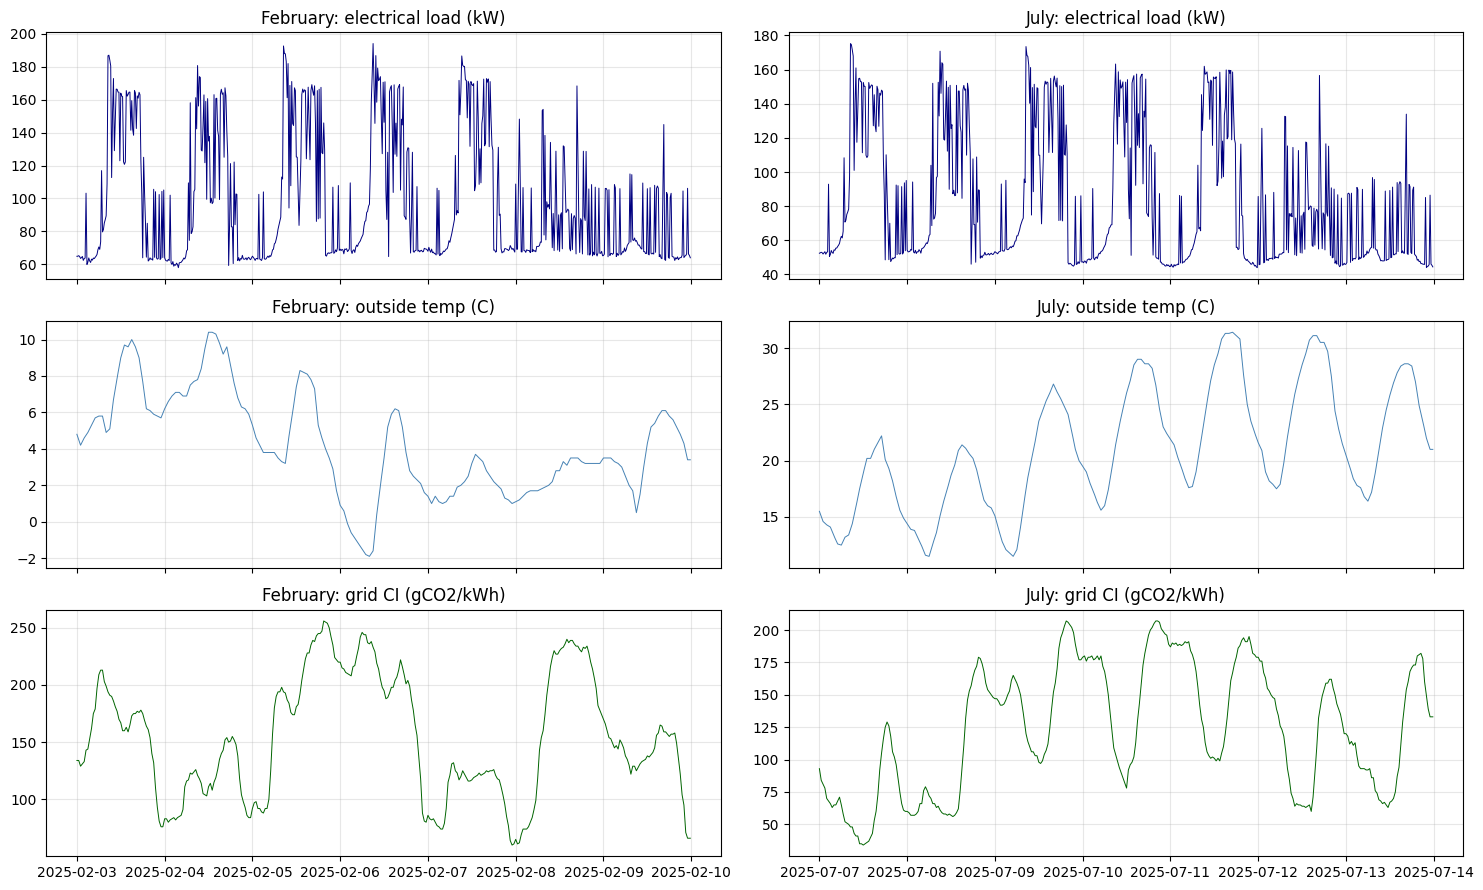

In [5]:
# Sanity plot, both seasons side by side
fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex="col")
for col, (df, lab) in enumerate([(df_feb, "February"), (df_jul, "July")]):
    axes[0, col].plot(df.index, df["total_load_kw"],
                      color="navy", linewidth=0.7)
    axes[0, col].set_title(f"{lab}: electrical load (kW)")
    axes[0, col].grid(alpha=0.3)
    axes[1, col].plot(df.index, df["outside_temp_c"],
                      color="steelblue", linewidth=0.7)
    axes[1, col].set_title(f"{lab}: outside temp (C)")
    axes[1, col].grid(alpha=0.3)
    axes[2, col].plot(df.index, df["grid_ci_gco2_per_kwh"],
                      color="darkgreen", linewidth=0.7)
    axes[2, col].set_title(f"{lab}: grid CI (gCO2/kWh)")
    axes[2, col].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("synthetic_two_season.png", dpi=150, bbox_inches="tight")
print("Saved synthetic_two_season.png")